Summarizing Results:

Math, reading, and writing score had the best distributions out of all of the variables.

I handled missing values by removing them at the beginning, but once I started trying to run my models it was saying that I had some missing values, so I decided to fill those missing values in with averages. This handled my problem.

I encoded categorical data by using label and one hot encoders, I used label encoding for the gender and test preparation course columns. I used one hot encoding for the race/ethnicity and parental level of education columns. I decided to use these methods because they could encode my columns without a ranking, and I could use 0 and 1 values for the gender and test prep columns because there were only two possible values. This sets it so that I can look at the data and go "Oh they're 0 or 1, there's no in betweens.

I personally decided not to remove any outliers, I could only see remvoing them for the three different subject scores that were collected, these being reading, math, and writing, but removing low scores wouldn't be productive here as we want to know what contributes to scoring poorly and scoring well.

I standardized the data using the standard scalar from skitlearn because it's a simple built-in way to make sure that the data will contribute equally within the machine learning models.

The models all performed similarly, I would say the SVM model performed best as it's R2 score is one of the higest, and the MSE and RMSE are both lower which is good.

Out of all the models, the decision tree had the highest MSE and RMSE, yet it had the lower R2 out of all of the models. This means that the decision tree model has higher bias and higher variance. 
The linear regression model has the highest R2 score, meaning this model has the low variance of the target explained by the predictors. It also has some low MSE and RMSE values, so this means that it has low bias.

In [1]:
import pandas as pd

In [2]:
studentDF = pd.read_csv("StudentsPerformance0.csv")

studentDF.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [3]:
def printAmtNa(aDF):
    for aCol in studentDF:
        print(f"The amount of missing values in {aCol} is {studentDF[aCol].isna().sum()}")

printAmtNa(studentDF)

The amount of missing values in gender is 0
The amount of missing values in race/ethnicity is 0
The amount of missing values in parental level of education is 0
The amount of missing values in lunch is 0
The amount of missing values in test preparation course is 4
The amount of missing values in math score is 0
The amount of missing values in reading score is 0
The amount of missing values in writing score is 0


In [8]:
import matplotlib.pyplot as plt 
def makeHistogram(studentDF, colName, width, height):
    """This function generates a bar chart with the value count for all values of a given
       and dataframe

    Args:
        myDF (DataFrame): Dataframe of Data
        colName (String): Name of Column in DataFrame
        width (float): width of figure
        height (float): height of figure
    """
    plt.figure(figsize=(width, height))
    plt.hist(studentDF[colName])
    plt.xlabel(colName, labelpad=14)
    plt.ylabel("Count", labelpad=14)
    plt.title(f"Distribution of {colName} Column", y=1.02)

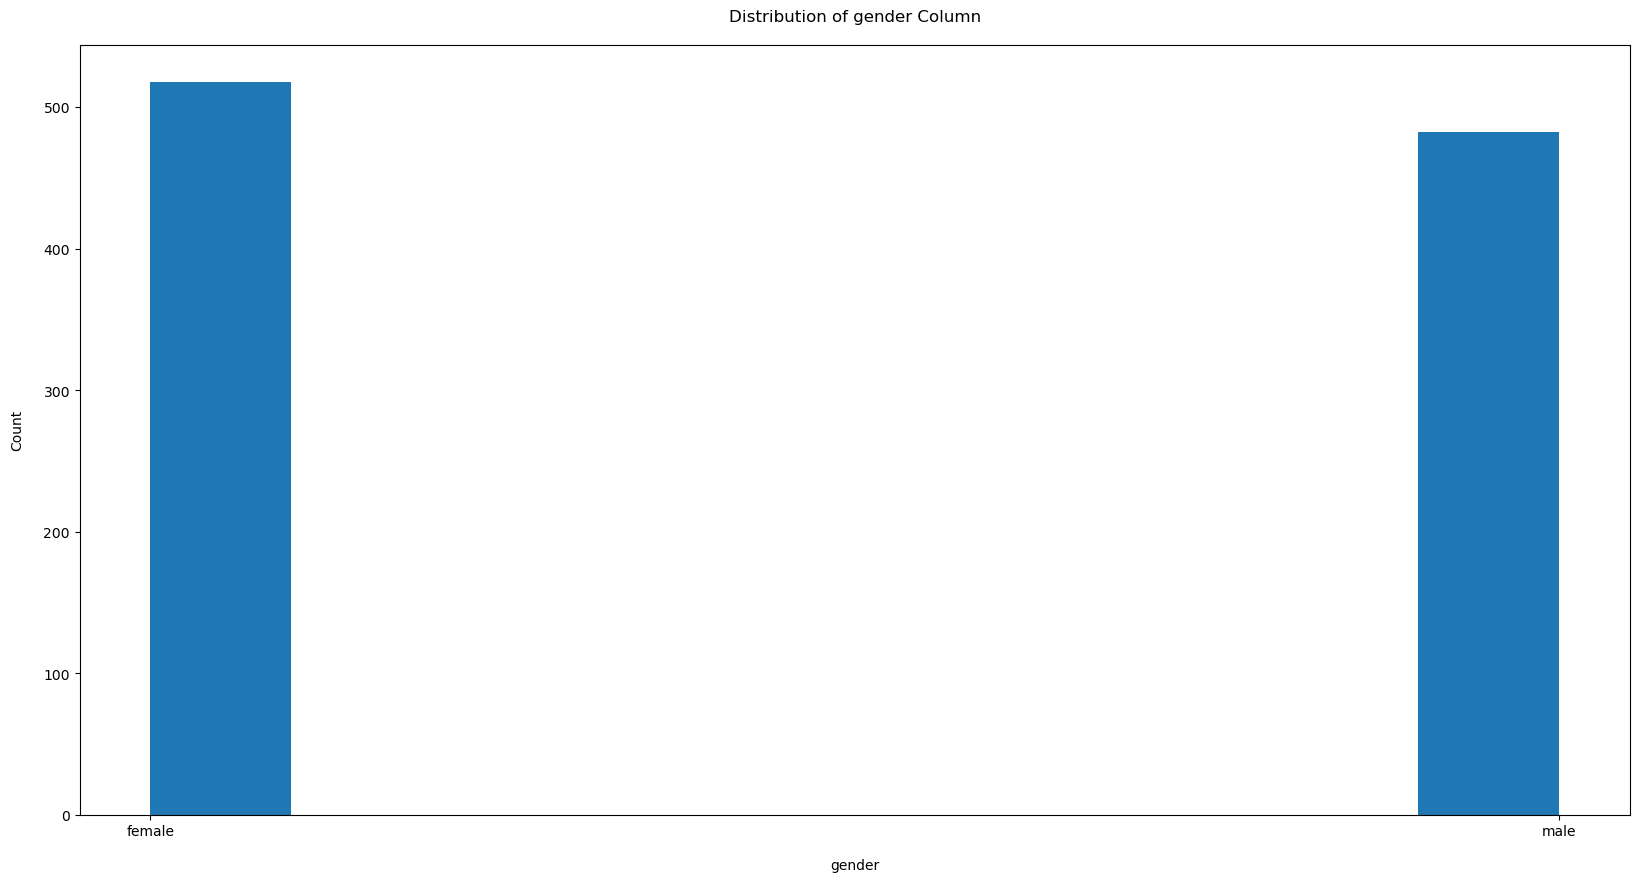

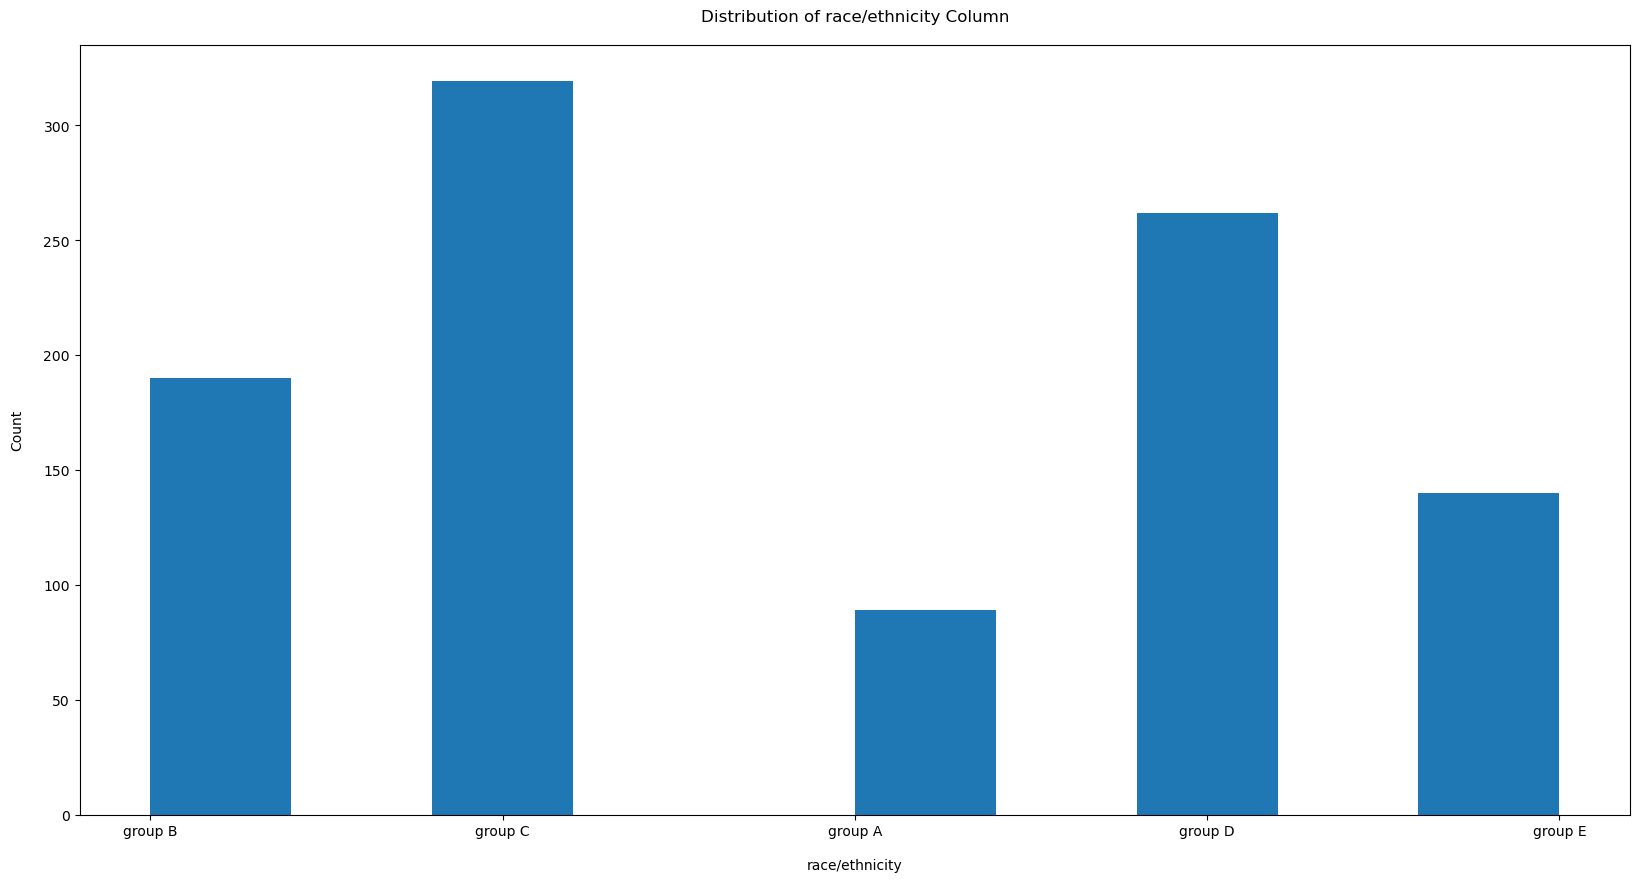

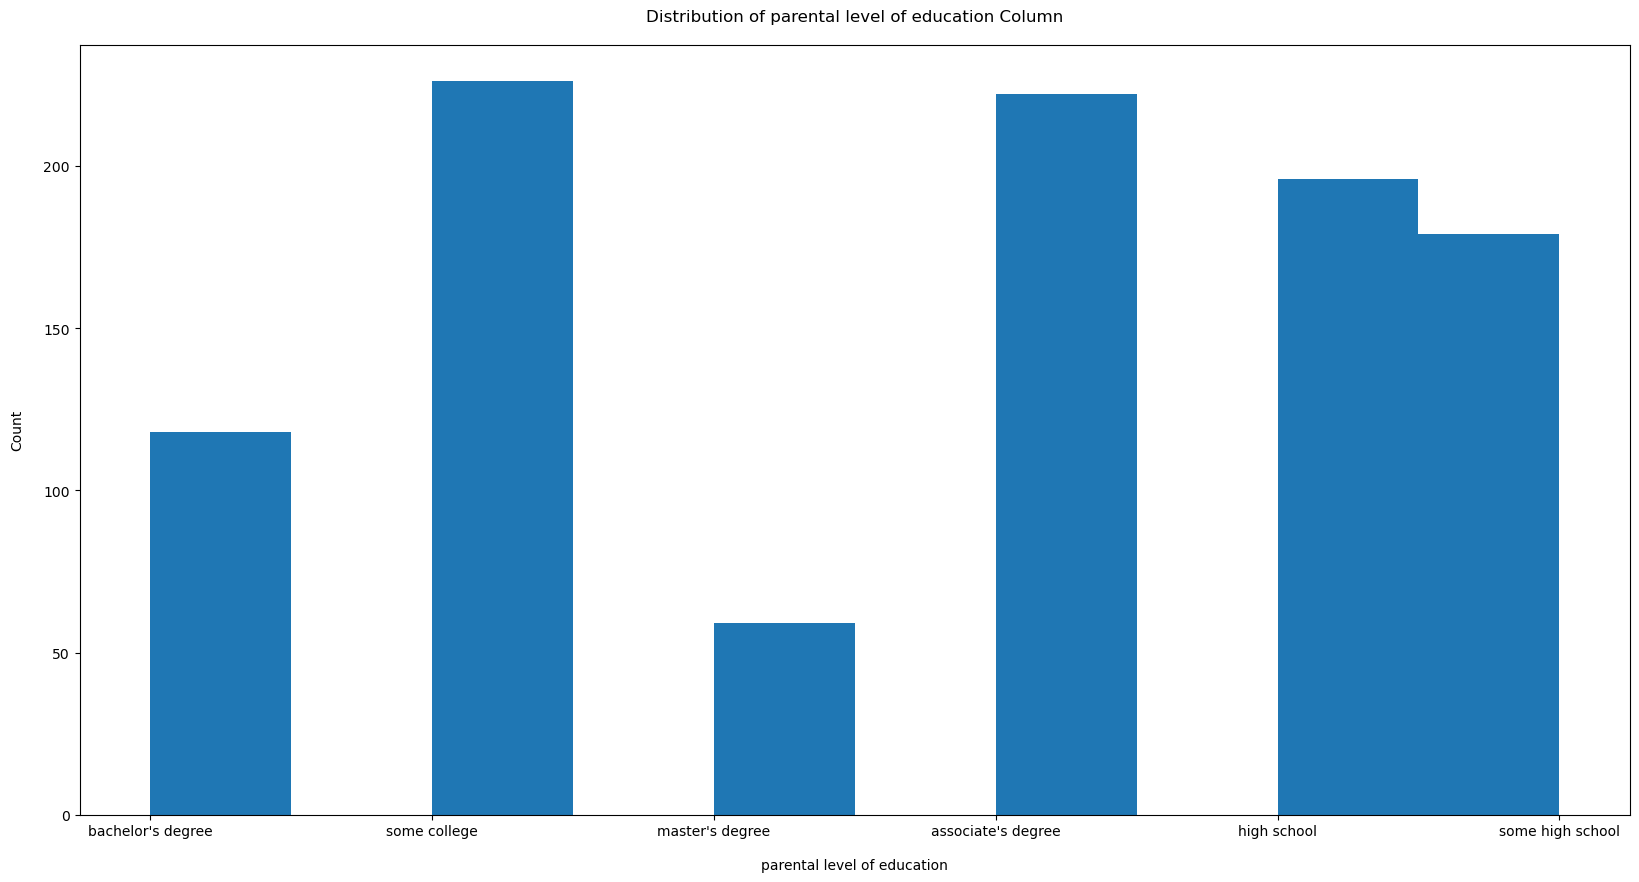

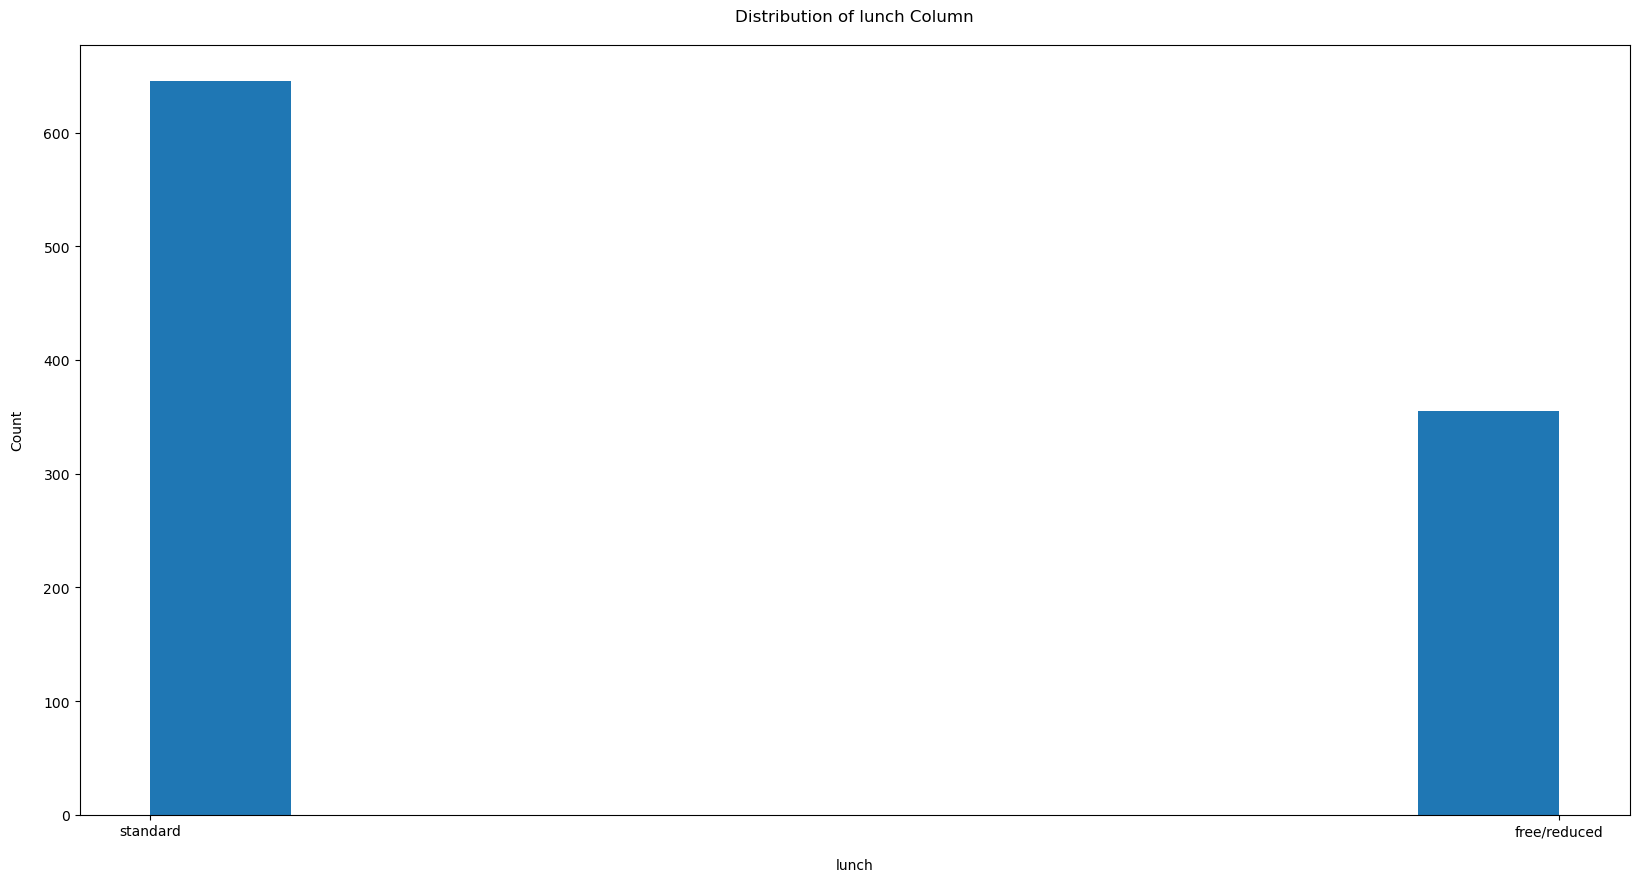

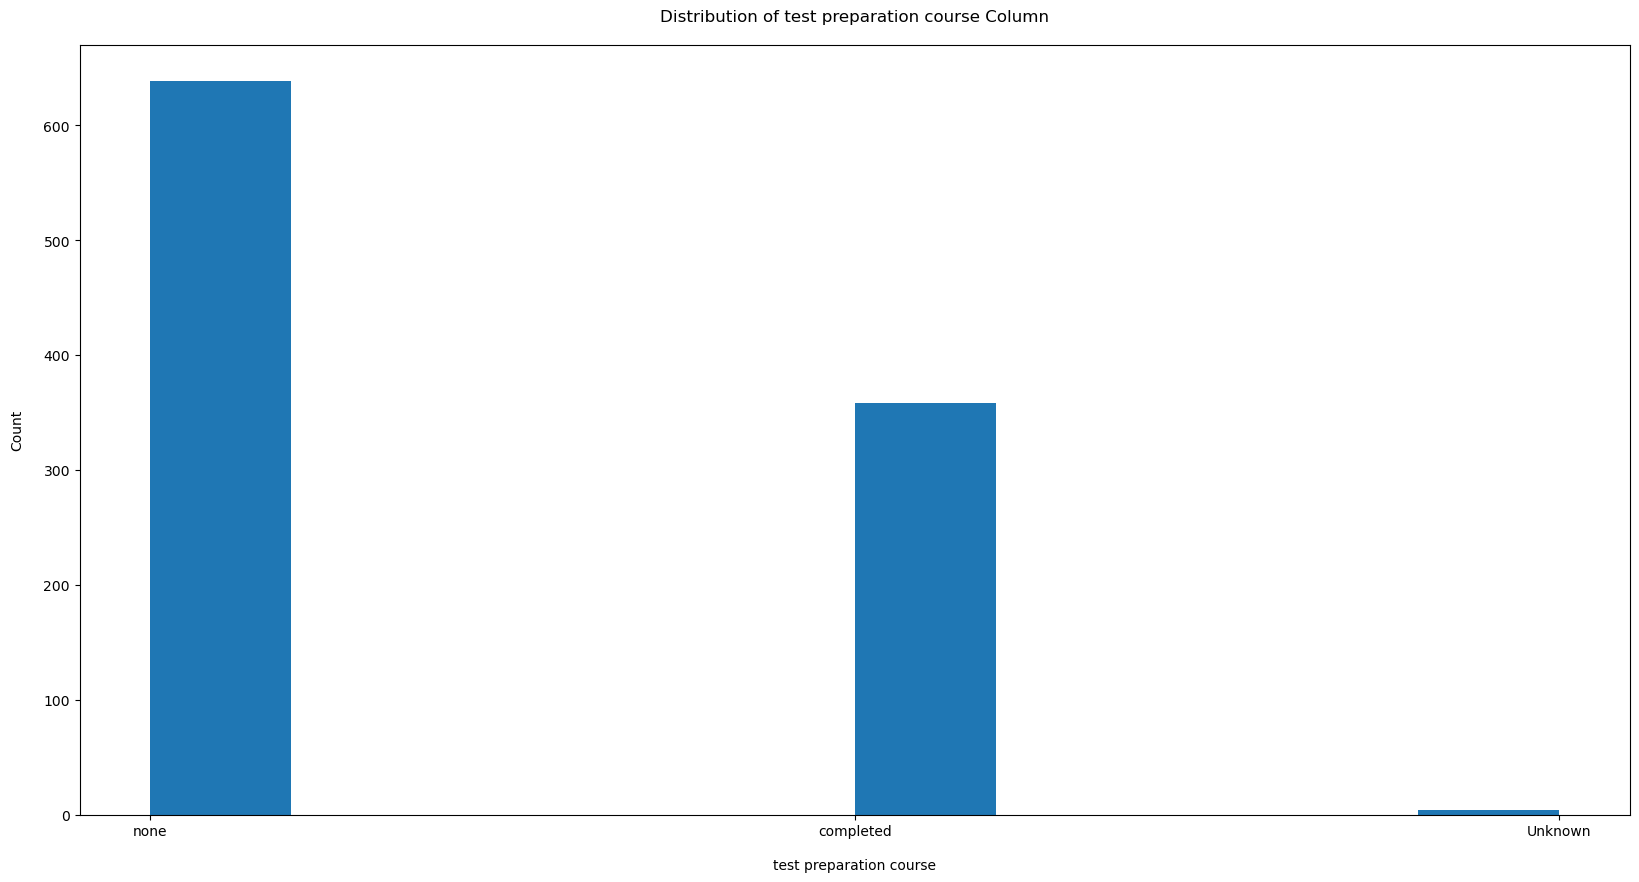

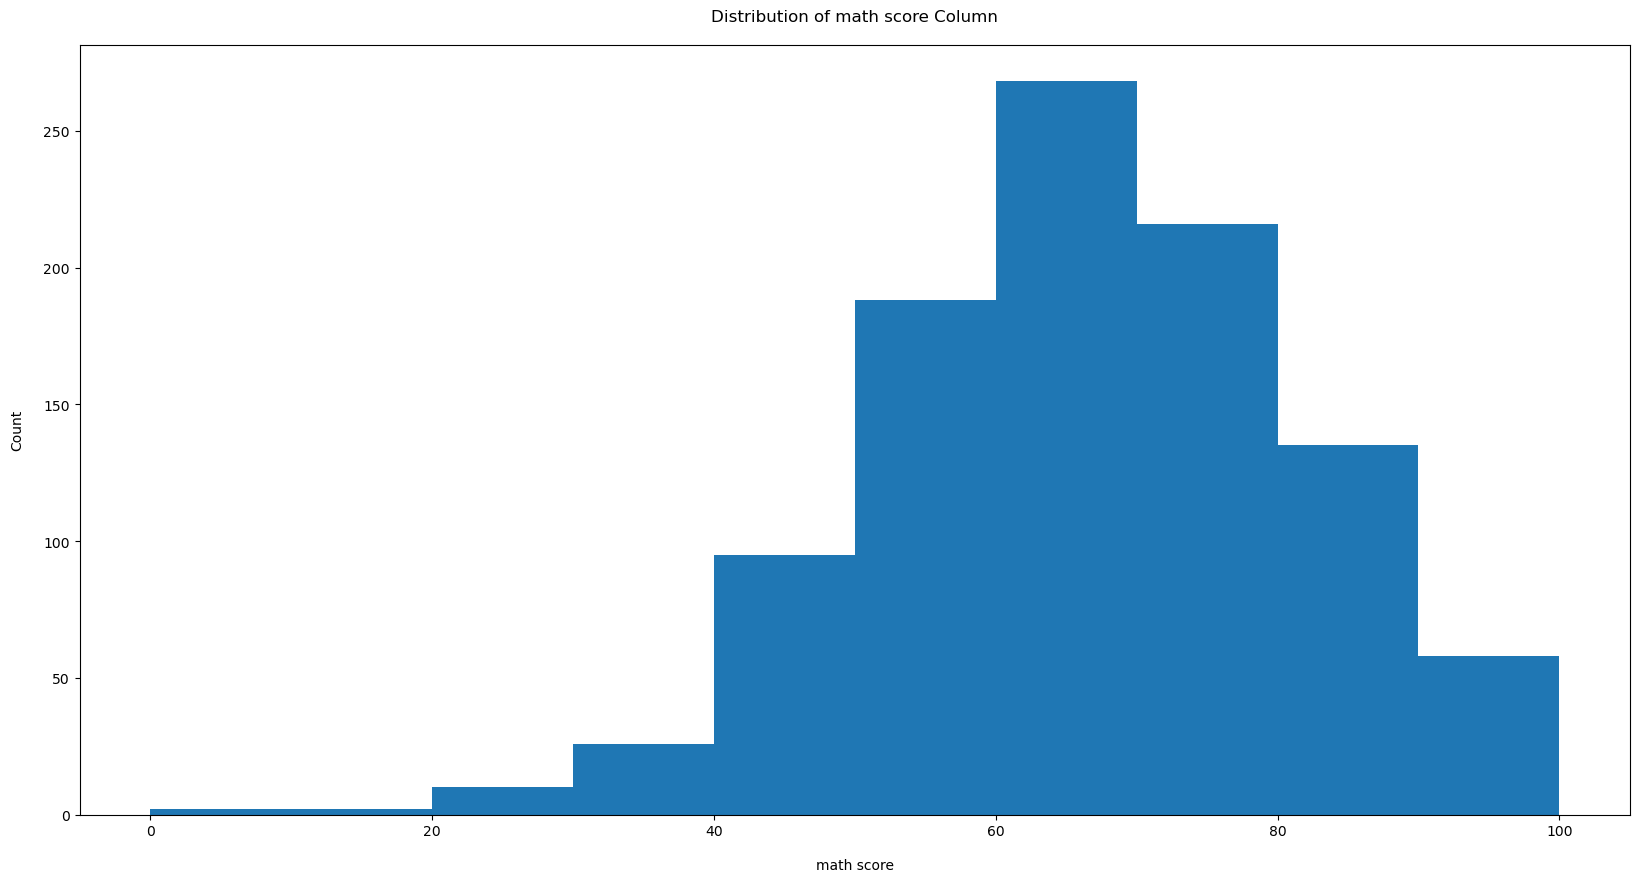

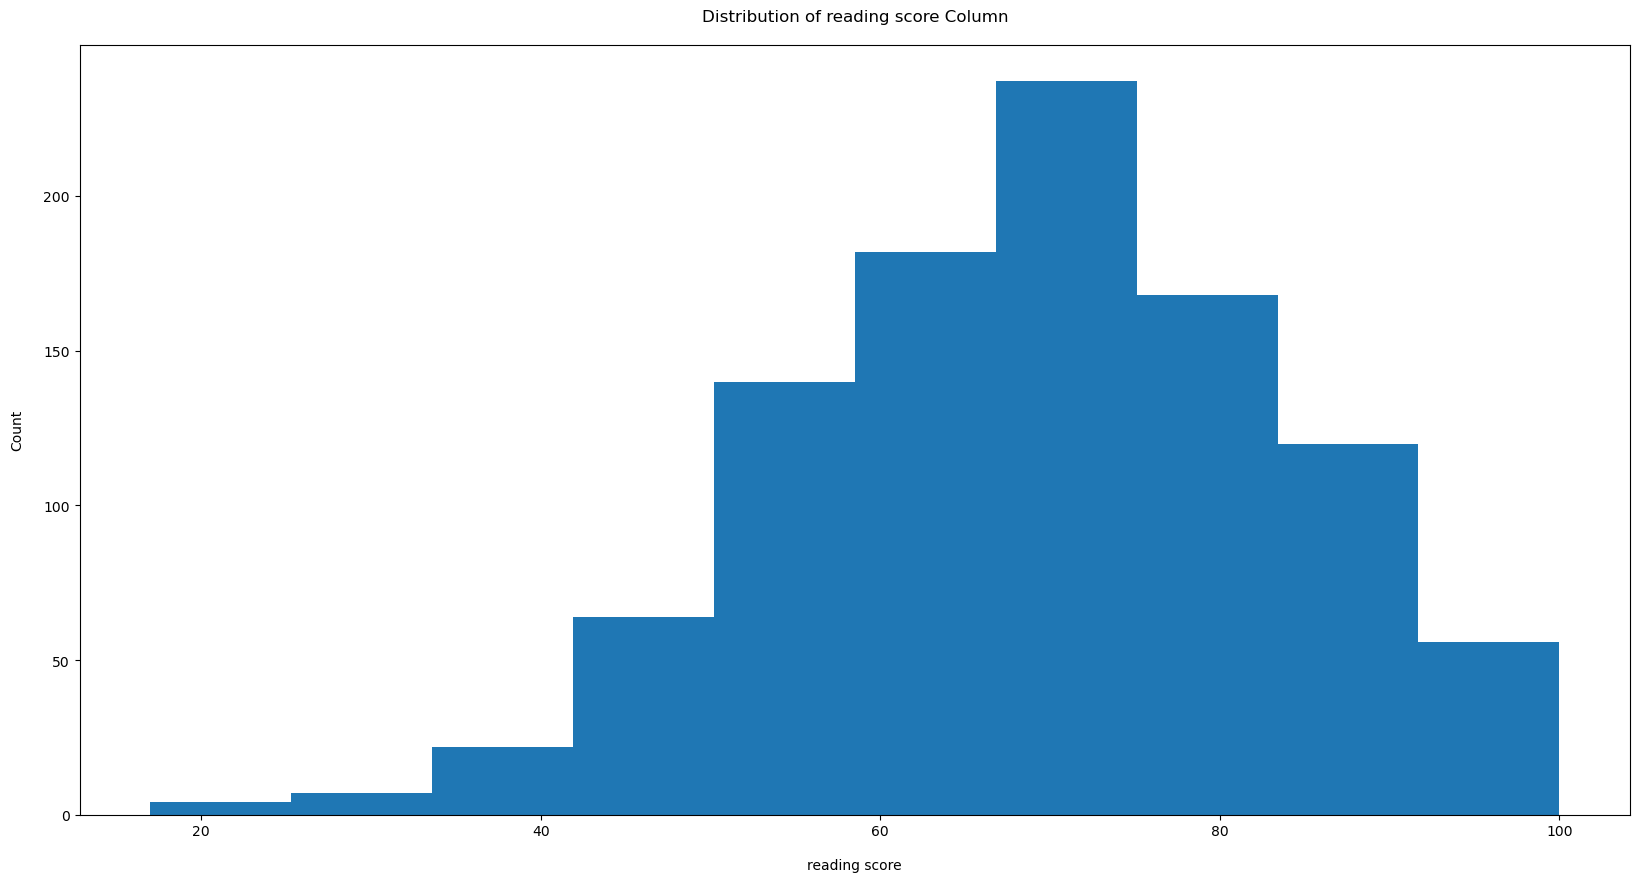

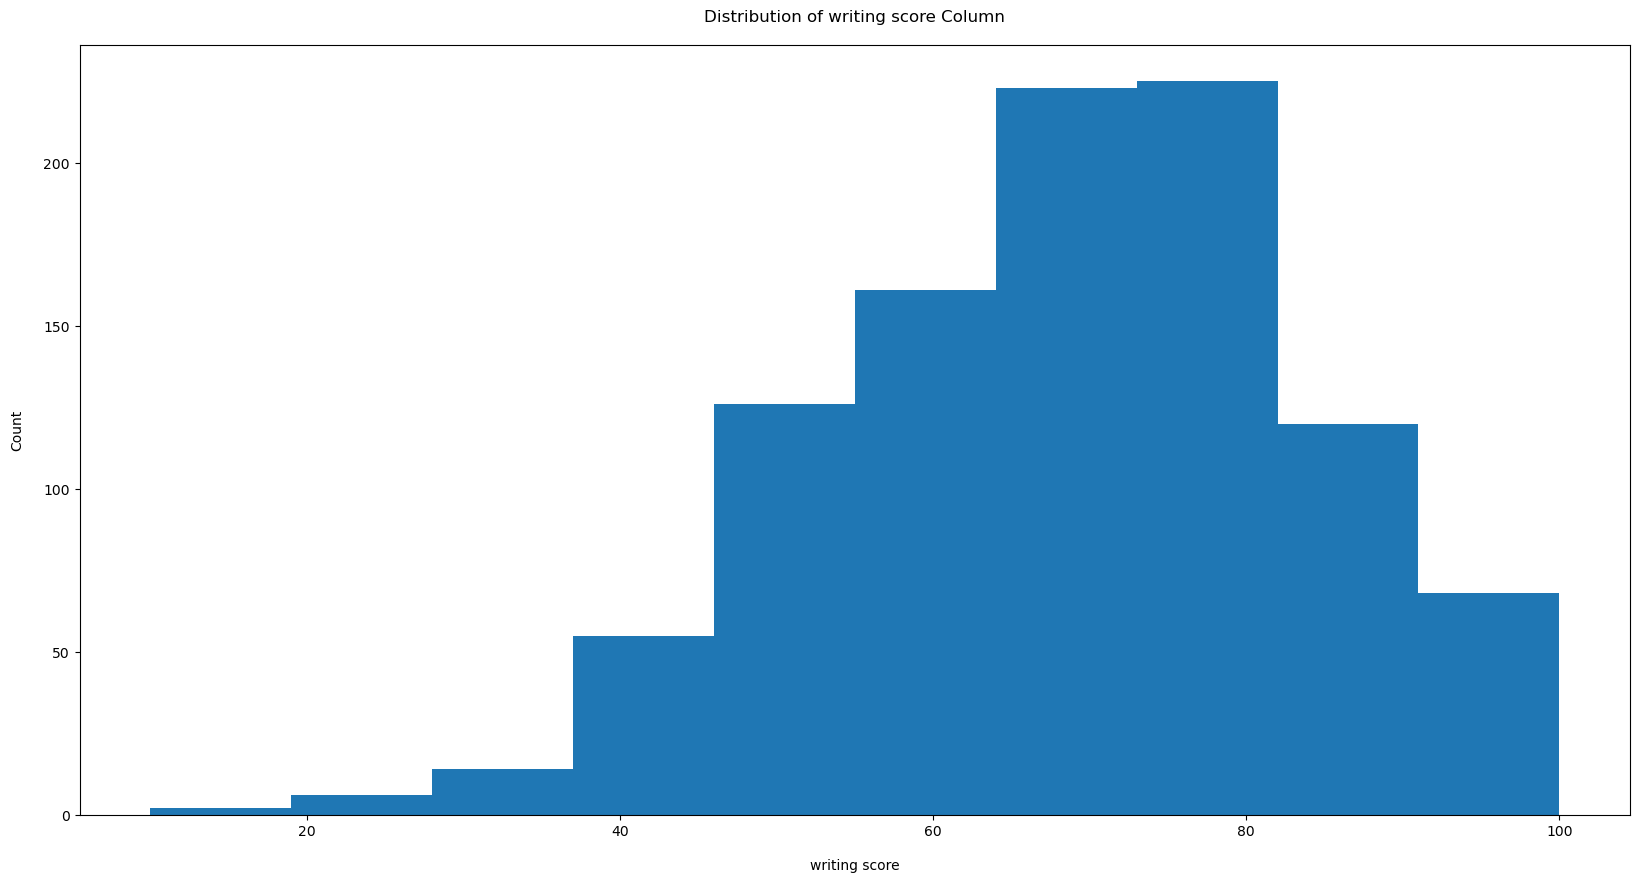

In [10]:
studentDF = studentDF.fillna('Unknown')

for col in studentDF:
   makeHistogram(studentDF, str(col), 20, 10)

In [ ]:
studentDF.shape

(1000, 8)

In [ ]:
studentDF = studentDF.dropna(axis=0)

studentDF

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77


<Axes: ylabel='math score'>

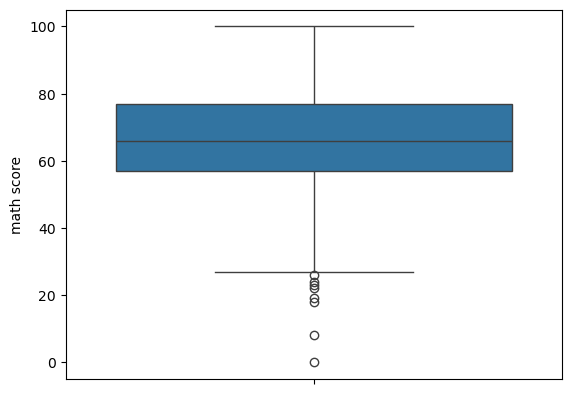

In [ ]:
import seaborn as sns
sns.boxplot(studentDF['math score'])

<Axes: ylabel='reading score'>

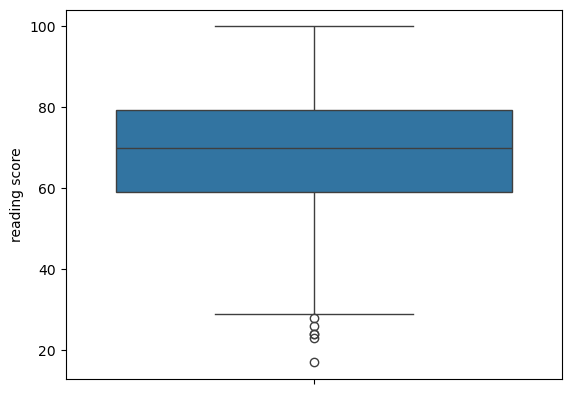

In [ ]:
sns.boxplot(studentDF['reading score'])

<Axes: ylabel='writing score'>

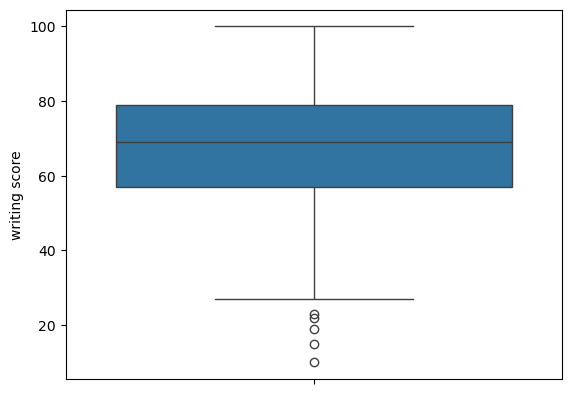

In [ ]:
sns.boxplot(studentDF['writing score'])

It seems as if math, reading, and writing scores do have outliers that are below most of the other average scores, but remoing these rows of data may lead to us not understanding what factors can contribute to getting low scores in these subjects.

Label encode the gender, type of lunch, and test prep completed columns.

In [ ]:
from sklearn.preprocessing import LabelEncoder

labelDF = studentDF.copy()

lab = LabelEncoder()

#perform label encoding on 'country' column
labelDF['gender'] = lab.fit_transform(labelDF['gender'])

labelDF.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,0,group B,bachelor's degree,standard,none,72,72,74
1,0,group C,some college,standard,completed,69,90,88
2,0,group B,master's degree,standard,none,90,95,93
3,1,group A,associate's degree,free/reduced,none,47,57,44
4,1,group C,some college,standard,none,76,78,75


Female will equal 0, and male will equal 1.

In [ ]:
labelDF["lunch"] = lab.fit_transform(labelDF["lunch"])

labelDF.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,0,group B,bachelor's degree,1,none,72,72,74
1,0,group C,some college,1,completed,69,90,88
2,0,group B,master's degree,1,none,90,95,93
3,1,group A,associate's degree,0,none,47,57,44
4,1,group C,some college,1,none,76,78,75


Standard lunch equals 1, and free/reduced equals 0.

In [ ]:
labelDF["test preparation course"] = lab.fit_transform(labelDF["test preparation course"])

labelDF.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,0,group B,bachelor's degree,1,1,72,72,74
1,0,group C,some college,1,0,69,90,88
2,0,group B,master's degree,1,1,90,95,93
3,1,group A,associate's degree,0,1,47,57,44
4,1,group C,some college,1,1,76,78,75


No test prep done equals 1, and completed test prep equals 0.

Moving on to one hot enoding, we will encode the race/ethnicity and parental level of education using this method.

In [ ]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False)

oneHotDF = studentDF.copy()

encodedData = encoder.fit_transform(oneHotDF[['race/ethnicity']])

encoder.categories_

[array(['group A', 'group B', 'group C', 'group D', 'group E'],
       dtype=object)]

In [ ]:
oneHotDF = pd.DataFrame(encodedData, columns=encoder.categories_)

oneHotDF.head()

,group A,group B,group C,group D,group E
0,0.0,1.0,0.0,0.0,0.0
1,0.0,0.0,1.0,0.0,0.0
2,0.0,1.0,0.0,0.0,0.0
3,1.0,0.0,0.0,0.0,0.0
4,0.0,0.0,1.0,0.0,0.0


In [ ]:
oneHotDF.columns = oneHotDF.columns.get_level_values(0)

halfCleanedDF = pd.concat([labelDF, oneHotDF], axis=1).drop(columns = "race/ethnicity")

halfCleanedDF.head()

,gender,parental level of education,lunch,test preparation course,math score,reading score,writing score,group A,group B,group C,group D,group E
0,0.0,bachelor's degree,1.0,1.0,72.0,72.0,74.0,0.0,1.0,0.0,0.0,0.0
1,0.0,some college,1.0,0.0,69.0,90.0,88.0,0.0,0.0,1.0,0.0,0.0
2,0.0,master's degree,1.0,1.0,90.0,95.0,93.0,0.0,1.0,0.0,0.0,0.0
3,1.0,associate's degree,0.0,1.0,47.0,57.0,44.0,1.0,0.0,0.0,0.0,0.0
4,1.0,some college,1.0,1.0,76.0,78.0,75.0,0.0,0.0,1.0,0.0,0.0


In [ ]:
encodedData = encoder.fit_transform(halfCleanedDF[['parental level of education']])

encoder.categories_

[array(["associate's degree", "bachelor's degree", 'high school',
        "master's degree", 'some college', 'some high school', nan],
       dtype=object)]

In [ ]:
oneHotDF = pd.DataFrame(encodedData, columns=encoder.categories_)

oneHotDF.head()

,associate's degree,bachelor's degree,high school,master's degree,some college,some high school,NaN
0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [ ]:
if 'NaN' in oneHotDF.columns:
    oneHotDF.drop('your_col_NaN', axis=1, inplace=True)

In [ ]:
oneHotDF.columns = oneHotDF.columns.get_level_values(0)

cleanedDF = pd.concat([halfCleanedDF, oneHotDF], axis=1).drop(columns = "parental level of education")

cleanedDF.head()

,gender,lunch,test preparation course,math score,reading score,writing score,group A,group B,group C,group D,group E,associate's degree,bachelor's degree,high school,master's degree,some college,some high school,NaN
0,0.0,1.0,1.0,72.0,72.0,74.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,0.0,1.0,0.0,69.0,90.0,88.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,0.0,1.0,1.0,90.0,95.0,93.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,1.0,0.0,1.0,47.0,57.0,44.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1.0,1.0,1.0,76.0,78.0,75.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [ ]:
yDF = pd.DataFrame(cleanedDF["reading score"])

yDF.head()

,reading score
0,72.0
1,90.0
2,95.0
3,57.0
4,78.0


In [ ]:
xDF = cleanedDF.drop(columns="reading score")

xDF.head()

,gender,lunch,test preparation course,math score,writing score,group A,group B,group C,group D,group E,associate's degree,bachelor's degree,high school,master's degree,some college,some high school,NaN
0,0.0,1.0,1.0,72.0,74.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,0.0,1.0,0.0,69.0,88.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,0.0,1.0,1.0,90.0,93.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,1.0,0.0,1.0,47.0,44.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1.0,1.0,1.0,76.0,75.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [ ]:
print(xDF.shape)
print(yDF.shape)

(1000, 17)
(1000, 1)


In [ ]:
# split training and testing set
from sklearn.model_selection import train_test_split

xTrain, xTest, yTrain, yTest = train_test_split(xDF,
                                                yDF,
                                                test_size = 0.3,
                                                shuffle=True)

xTrain.head()

,gender,lunch,test preparation course,math score,writing score,group A,group B,group C,group D,group E,associate's degree,bachelor's degree,high school,master's degree,some college,some high school,NaN
783,0.0,1.0,0.0,52.0,62.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
503,0.0,1.0,0.0,95.0,92.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
244,1.0,1.0,1.0,75.0,69.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
85,0.0,1.0,1.0,73.0,82.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
609,0.0,1.0,1.0,58.0,65.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
yTrain.head()

,reading score
783,59.0
503,89.0
244,74.0
85,80.0
609,63.0


In [ ]:
# Standardization
from sklearn.preprocessing import StandardScaler
import pickle

xScaler = StandardScaler()
yScaler = StandardScaler()

xColNames = xTrain.columns.values.tolist()

xTrain.columns = xTrain.columns.astype(str)
xTest.columns = xTest.columns.astype(str)

xTrain[xColNames] = xScaler.fit_transform(xTrain[xColNames])

# lets save our sScaler for later predictions
with open("xScaler_CityHappiness.pkl", 'wb') as f:
    pickle.dump(xScaler, f)

yColNames = yTrain.columns.values.tolist()

yTrain[yColNames] = yScaler.fit_transform(yTrain[yColNames])

# lets save our one hot encoder for later predictions
with open("yScaler_CityHappiness.pkl", 'wb') as f:
    pickle.dump(yScaler, f)

xTrain.head()

,gender,lunch,test preparation course,math score,writing score,group A,group B,group C,group D,group E,associate's degree,bachelor's degree,high school,master's degree,some college,some high school,nan
783,-0.923972,0.74087,-1.304435,-0.915600,-0.394415,-0.301275,2.021779,-0.685904,-0.596683,-0.399667,-0.513359,-0.388993,-0.470787,-0.262111,1.859731,-0.477567,-0.065606
503,-0.923972,0.74087,-1.304435,1.964788,1.552522,-0.301275,2.021779,-0.685904,-0.596683,-0.399667,-0.513359,2.570738,-0.470787,-0.262111,-0.537712,-0.477567,-0.065606
244,1.082284,0.74087,0.766615,0.625072,0.059870,-0.301275,2.021779,-0.685904,-0.596683,-0.399667,-0.513359,-0.388993,2.124102,-0.262111,-0.537712,-0.477567,-0.065606
85,-0.923972,0.74087,0.766615,0.491101,0.903543,-0.301275,-0.494614,-0.685904,1.675931,-0.399667,-0.513359,-0.388993,-0.470787,-0.262111,-0.537712,2.093947,-0.065606
609,-0.923972,0.74087,0.766615,-0.513686,-0.199722,-0.301275,-0.494614,1.457930,-0.596683,-0.399667,1.947953,-0.388993,-0.470787,-0.262111,-0.537712,-0.477567,-0.065606


In [ ]:
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import root_mean_squared_error
from sklearn.linear_model import LinearRegression

xTrain = xTrain.fillna(xTrain.mean())
xTest = xTest.fillna(xTrain.mean())

yTrain = yTrain.fillna(yTrain.mean())
yTest = yTest.fillna(yTrain.mean())

linearModel = LinearRegression().fit(xTrain, yTrain)
preds = linearModel.predict(xTest)

# lets save our model for later predictions
with open("linear_StudentPerformance.pkl", 'wb') as f:
    pickle.dump(linearModel, f)

print(f"R squared: {r2_score(yTest, preds)}")
print(f" MAE: {mean_absolute_error(yTest, preds)}")
print(f"RMSE: {root_mean_squared_error(yTest, preds)}")

R squared: 0.9082475932038004
 MAE: 3.7267470163352527
RMSE: 4.5517072681922475


In [ ]:
from sklearn import svm

svmModel = svm.SVR().fit(xTrain, yTrain)

# lets save our svm for later predictions
with open("svm_CityHappiness.pkl", 'wb') as f:
    pickle.dump(svmModel, f)

preds = svmModel.predict(xTest)

print(f"R squared: {r2_score(yTest, preds)}")
print(f" MAE: {mean_absolute_error(yTest, preds)}")
print(f"RMSE: {root_mean_squared_error(yTest, preds)}")

R squared: 0.8778586314843322
 MAE: 3.8182664887256115
RMSE: 4.75344832898549


c:\Users\kathr\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [ ]:
from sklearn import tree

dtModel = tree.DecisionTreeRegressor(max_depth=3).fit(xTrain, yTrain)

# lets save our decision tree for later predictions
with open("dt_CityHappiness.pkl", 'wb') as f:
    pickle.dump(dtModel, f)

preds = dtModel.predict(xTest)

print(f"R squared: {r2_score(yTest, preds)}")
print(f" MAE: {mean_absolute_error(yTest, preds)}")
print(f"RMSE: {root_mean_squared_error(yTest, preds)}")

R squared: 0.8622272228582331
 MAE: 4.087683314475449
RMSE: 5.048462014832494


In [ ]:
from sklearn.neural_network import MLPRegressor

nnModel = MLPRegressor().fit(xTrain, yTrain)

# lets save our neural network for later predictions
with open("nn_CityHappiness.pkl", 'wb') as f:
    pickle.dump(nnModel, f)

preds = nnModel.predict(xTest)

print(f"R squared: {r2_score(yTest, preds)}")
print(f" MAE: {mean_absolute_error(yTest, preds)}")
print(f"RMSE: {root_mean_squared_error(yTest, preds)}")

c:\Users\kathr\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:1771: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


R squared: 0.9062494648961038
 MAE: 3.4090965978386363
RMSE: 4.164513403307916


c:\Users\kathr\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
